In [61]:
import os

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import datetime as dt

In [63]:
liker_sales = pd.read_csv("train.csv")

In [64]:
liker_sales = liker_sales.drop(['liker','product'], axis=1)

In [65]:
liker_sales['date'] = pd.to_datetime(liker_sales['date'])

Convert date to a Month period, and the sum the number of items in each month

In [66]:
liker_sales['date'] = liker_sales['date'].dt.to_period('M')
monthly_sales = liker_sales.groupby('date').sum().reset_index()
monthly_sales['date'] = monthly_sales['date'].dt.to_timestamp()

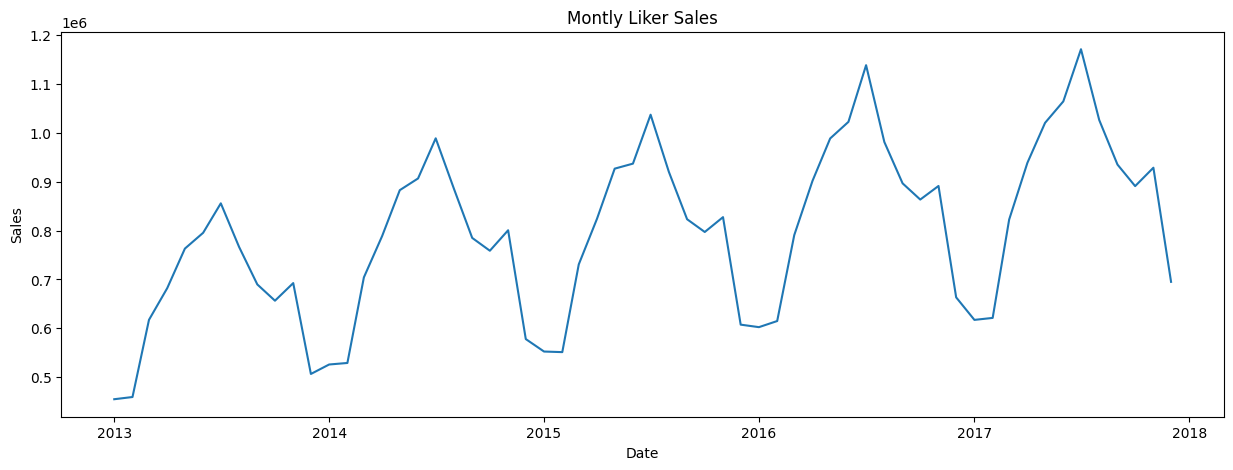

In [67]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['date'],monthly_sales['sales'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Montly Liker Sales")
plt.show()

In [68]:
monthly_sales['sales_diff'] = monthly_sales['sales'].diff()
monthly_sales = monthly_sales.dropna()

In [69]:
supervised_data = monthly_sales.drop(['date','sales'],axis=1)

for i in range(1,13):
  col_name = 'month_' + str(i)
  supervised_data[col_name] = supervised_data['sales_diff'].shift(i)

supervised_data = supervised_data.dropna().reset_index(drop=True)

Split data in train , test. And scale them

In [70]:
train_data = supervised_data[:-12]
test_data = supervised_data[-12:]

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(train_data)

train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

In [71]:
x_train, y_train = train_data[:,1:], train_data[:,0:1]
x_test, y_test = test_data[:,1:], test_data[:,0:1]

y_train = y_train.ravel()
y_test = y_test.ravel()


In [72]:
sales_dates = monthly_sales['date'][-12:].reset_index(drop=True)
predict_df = pd.DataFrame(sales_dates)

In [73]:
actual_sales = monthly_sales['sales'][-13:].to_list()

Linear regression model

In [74]:
lr_model = LinearRegression()

lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

lr_pred = lr_pred.reshape(-1,1)
lr_pred_test_set = np.concatenate([lr_pred, x_test], axis=1)
lr_pred_test_set = scaler.inverse_transform(lr_pred_test_set)

In [75]:
result_list = []
for index in range(0, len(lr_pred_test_set)):
  result_list.append(lr_pred_test_set[index][0] + actual_sales[index])

lr_pred_series = pd.Series(result_list, name="Linear Prediction")
predict_df = predict_df.join(lr_pred_series)

Linear Regression MSE: 16221.272385416869
Linear Regression MAE: 12433.184266490736
Linear Regression R2 Score: 0.9906152516380969


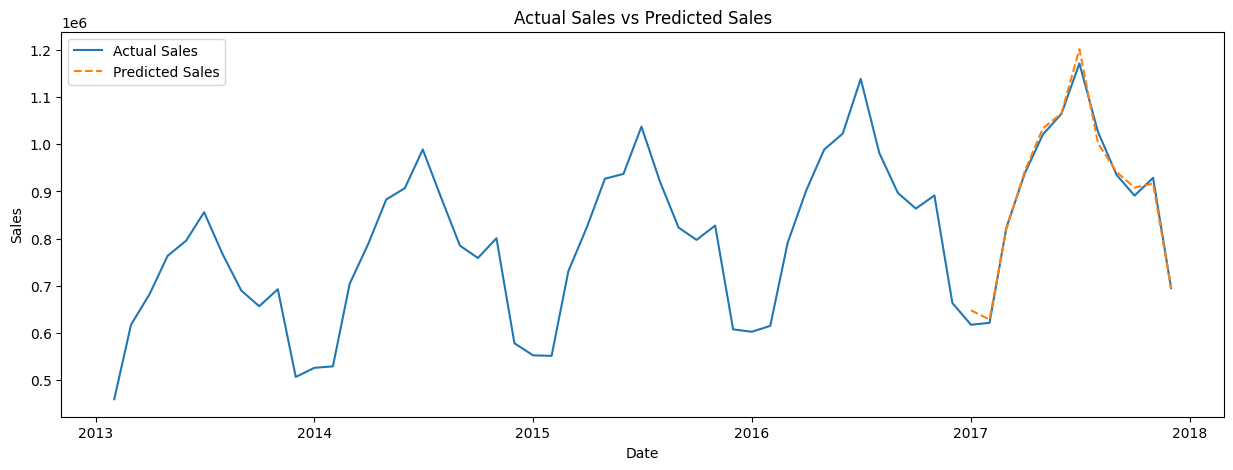

In [76]:
# Model Evaluation
lr_mse = np.sqrt(mean_squared_error(predict_df["Linear Prediction"], monthly_sales['sales'][-12:]))
lr_mae = mean_absolute_error(predict_df["Linear Prediction"], monthly_sales['sales'][-12:])
lr_r2 = r2_score(predict_df["Linear Prediction"], monthly_sales['sales'][-12:])

print(f"Linear Regression MSE: {lr_mse}")
print(f"Linear Regression MAE: {lr_mae}")
print(f"Linear Regression R2 Score: {lr_r2}")

# Plotting actual sales vs predicted sales
plt.figure(figsize=(15, 5))
plt.plot(monthly_sales['date'], monthly_sales['sales'], label="Actual Sales")
plt.plot(predict_df['date'], predict_df['Linear Prediction'], label='Predicted Sales', linestyle='--')
plt.title('Actual Sales vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()